# Conditional Graph

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END 

c:\Users\dhana\LangGraph\Agent-1\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    finalNumber: int

In [7]:
def adder(state:AgentState) -> AgentState:
    """This node adds 2 numbers"""

    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def substractor(state:AgentState) -> AgentState:
    """This node substracts 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next ndoe of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    
    elif state["operation"] == "-":
        return "substraction_operation"
    

In [10]:
graph = StateGraph(AgentState)

graph.add_node("adder_node", adder)
graph.add_node("substractor_node", substractor)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "adder_node",
        "substraction_operation": "substractor_node"
    }
)

graph.add_edge("adder_node", END)
graph.add_edge("substractor_node", END)

app = graph.compile()

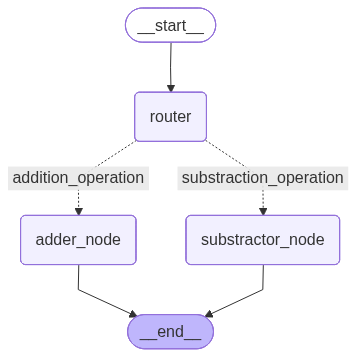

In [11]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
initial_state_1 = AgentState(number1 = 10, number2 = 5, operation="-")
print(app.invoke(initial_state_1))

{'number1': 10, 'number2': 5, 'operation': '-', 'finalNumber': 5}


In [13]:
initial_state_2 = AgentState(number1 = 10, number2 = 5, operation="+")
print(app.invoke(initial_state_2))

{'number1': 10, 'number2': 5, 'operation': '+', 'finalNumber': 15}
